In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

data = pd.read_csv('bikes_rent.csv')
X_bikes = data.drop(columns=['windspeed(mph)'])
X_scaled = StandardScaler().fit_transform(X_bikes)

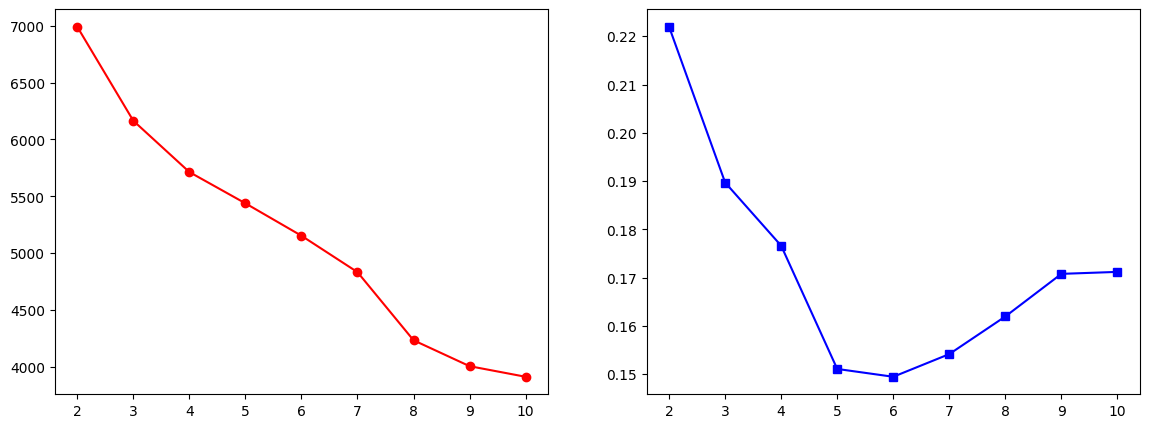

In [2]:
metrics_sil = []
metrics_inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    preds = kmeans.fit_predict(X_scaled)
    metrics_sil.append(silhouette_score(X_scaled, preds))
    metrics_inertia.append(kmeans.inertia_)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(k_range, metrics_inertia, marker='o', color='red')
ax2.plot(k_range, metrics_sil, marker='s', color='blue')
plt.show()

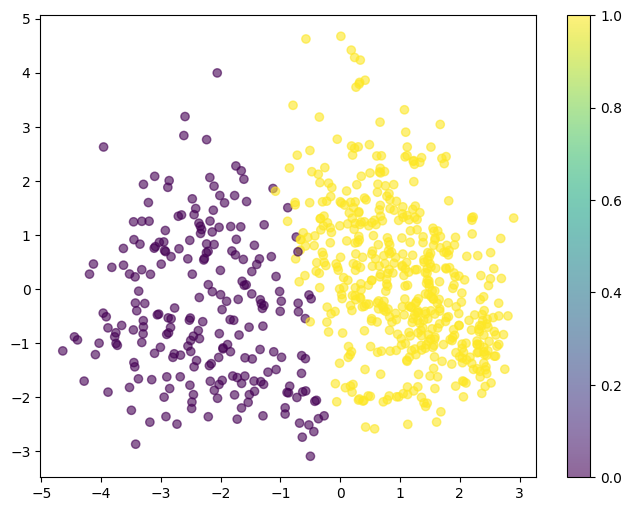

In [3]:
optimal_k = 2
final_model = KMeans(n_clusters=optimal_k, random_state=42)
data['Cluster'] = final_model.fit_predict(X_scaled)

pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(pca_2d[:, 0], pca_2d[:, 1], c=data['Cluster'], cmap='viridis', alpha=0.6)
plt.colorbar()
plt.show()

In [4]:
print(data.groupby('Cluster')[['temp', 'atemp', 'hum', 'cnt']].mean())

              temp      atemp        hum          cnt
Cluster                                              
0        12.928349  15.641029  57.513419  2741.327586
1        23.743087  27.472784  65.242370  5324.030060
